This code works with global mean values. It computes k and L and their timeseries starting from global mean files.

In [ ]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

# Dask will automatically submit SLURM jobs for you
cluster = SLURMCluster(
    cores=8,
    memory="128GB",
    processes=8,
    walltime="08:00:00",
    #qos="np",
    #account='spitfabi',
    #interface='ib0'  # or 'eth0', depends on your HPC
    job_extra_directives=[
        "--account=spitvent",
        "--qos=np"
        # "--constraint=haswell",
        # "--exclusive",
        # "--mail-type=END,FAIL",
        # "--mail-user=your.email@domain.com"
    ]
)

# Scale to desired number of workers
cluster.scale(jobs=1)  # This submits 1 SLURM job
# Connect client
client = Client(cluster)
#cluster.adapt(minimum_jobs=1, maximum_jobs=4)


/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38481 instead
  warnings.warn(


Task exception was never retrieved
future: <Task finished name='Task-30865' coro=<Client._gather.<locals>.wait() done, defined at /perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:2384> exception=AllExit()>
Traceback (most recent call last):
  File "/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py", line 2393, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-36268' coro=<Client._gather.<locals>.wait() done, defined at /perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:2384> exception=AllExit()>
Traceback (most recent call last):
  File "/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py", line 2393, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-83818' coro=<Client._gather.<locals>.wait() done, defined at /p

In [2]:
import check_run as cr
from matplotlib import pyplot as plt
import xarray as xr
import os
from scipy import stats
import numpy as np
import importlib as imp

In [3]:
read_again = []

cart_exp = '/ec/res4/scratch/{}/ece4/'
cart_out = '/ec/res4/hpcperm/itcv/analysis/'


In [4]:
exps = [ ['pct6', 'pic6'], ['pct7', 'pic7'],['pct1', 'pic1'], ['pct3', 'pic3'], ['pct2', 'pic2'], ['pct4', 'pic4'], ['1pc0', 'ctl0']]
colors=['violet', 'purple', 'orange', 'indianred','steelblue','forestgreen', 'maroon']

# anomalies with time

In [19]:
#fig, ax = plt.subplots(1,1)
imp.reload(cr)
for i, exp in enumerate(exps):
    cr.compute_base_anom_state(exps[i], 2*['itcv'], ref_exp=exps[i][1], color=colors[i],cart_exp=cart_exp, cart_out=cart_out)
plt.show()

pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..


tas
Pi: 287.72331963122735
Year 70: 2.3460411198163076
Year 150: 4.684880981423847
siconc_N
Pi: 14479455120014.584
Year 70: -4602038499533.555
Year 150: -8518736037497.075
qt_oce
Pi: 0.4003063120682956
Year 70: 1.2189154726126885
Year 150: 2.0308467402290478
msftyz
Pi: 17.27849
Year 70: -0.9250783588680525
Year 150: -7.8266091967847435
<xarray.DataArray 'Nsquared' (exp: 1, depth_mid: 30, y: 148, x: 180)> Size: 6MB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

KeyError: 'e3t'

-0.789938019327364


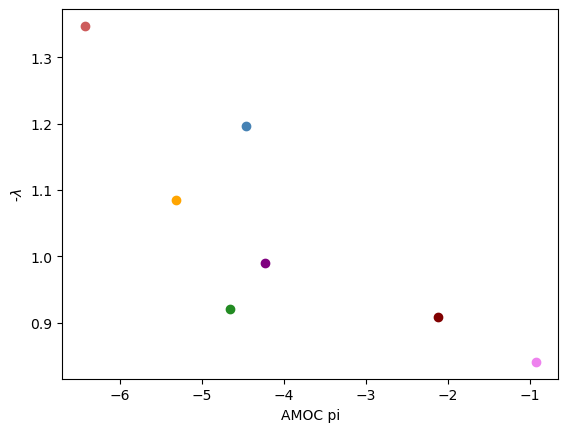

In [5]:
tas_pi = [287.72331963122735, 286.89837511887276, 286.79983021803463, 287.4171317625016, 287.24144629804425, 287.1969426407914, 287.32572009904766]
tas_year70 = [2.3460411198163076, 2.2170519074516752, 2.0646596355268514, 1.6655365417645518, 1.963871167161966, 2.1608291586707233, 2.3434379318936864]
tas_year150 = [4.684880981423847, 4.914090098290976, 4.968566532431445, 3.966455030873374, 4.368913006069293, 4.782327114075823, 4.807720646645491]

siconc_N_pi = [14479455120014.584, 15994627576789.732, 16021860805052.293, 11979478829014.707, 13679225882566.244, 14851995525745.688, 15229331364694.44]
siconc_N_year70 = [-4602038499533.555, -3775316835190.745, -3003776018107.728, -1398979682863.561, -2758987966015.9204, -3607375251412.6655, -4362570227519.58]
siconc_N_year150 = [-8518736037497.075, -8888201506764.545, -8959762984728.107, -4450677466047.324, -6601610799004.839, -8241223568651.684, -9244521521431.898]

msftyz_pi = [17.27849, 14.215454, 14.449981, 21.983986, 18.237486, 17.063816, 16.100374]
msftyz_year70 = [-0.9250783588680525, -4.234177262913042, -5.316252100566611, -6.429226397324655, -4.4645105609183044, -4.662816162446767, -2.117775940722199]
msftyz_year150 = [-7.8266091967847435, -6.692837732828652, -6.557082293575497, -13.536326667109822, -10.160338638268026, -8.554489324126747, -6.777226171078429]

# amoc_pi = [17.27849,14.215454,14.449981,21.983986,18.237486,17.063816,16.100374]
# amoc_pi_std = [1.1403457,2.1107132,1.9429334, 1.2809013,0.77734,1.3703792,1.3135902]
# seaice_std = [405075557049.7758, 433876509918.1365, 472723726459.2584, 221053308197.8054, 207480685962.43256, 448833222310.10394, 402170970559.5815]

# seaices = [3479090703649.175, 4099567375796.3125, 4619282539881.33, 3435313721430.905, 3284684082526.855, 4231256249354.605, 2948501343569.0996 ]
# seaices_std=[628636283403.251, 803815077435.8164, 776059608075.3014, 267517893869.95462, 374201092479.30853, 537986251273.3672, 655913220110.1863]

kappas = [0.84123329, 0.99007471, 1.0855393 , 1.3471938 , 1.19594174,0.92113063, 0.90884158]
lambdas = [1.15206076, 1.15950603, 1.26772497, 1.4947282 , 1.30711237,1.2470465 , 1.12615353]

# year 150 anomalies
#std = [0.12393996249944986,0.14452717105276336, 0.1565853087895551, 0.08134038510770378, 0.09048955828462242, 0.11208658537008717, 0.12362422538390468]
#std_int = [0.07939380726501576, 0.09350129175622988, 0.07413722534207776, 0.0603842729025888, 0.050400313785340135, 0.0711696066475429, 0.05804515988786692]
#std_30 = [0.11344099983406405 , 0.11524507438070272 , 0.09603061569359474 , 0.05705723329642595 , 0.08221599603466306 ,0.09790018873966021, 0.08147668405308067]

for i in range(7):
    plt.errorbar(msftyz_year70[i],kappas[i], fmt='o', color=colors[i])

_,_,r,_,_ = stats.linregress(kappas,msftyz_year150)
print(r)

plt.xlabel(r'AMOC pi')
plt.ylabel(r'-$\lambda$')
plt.show()

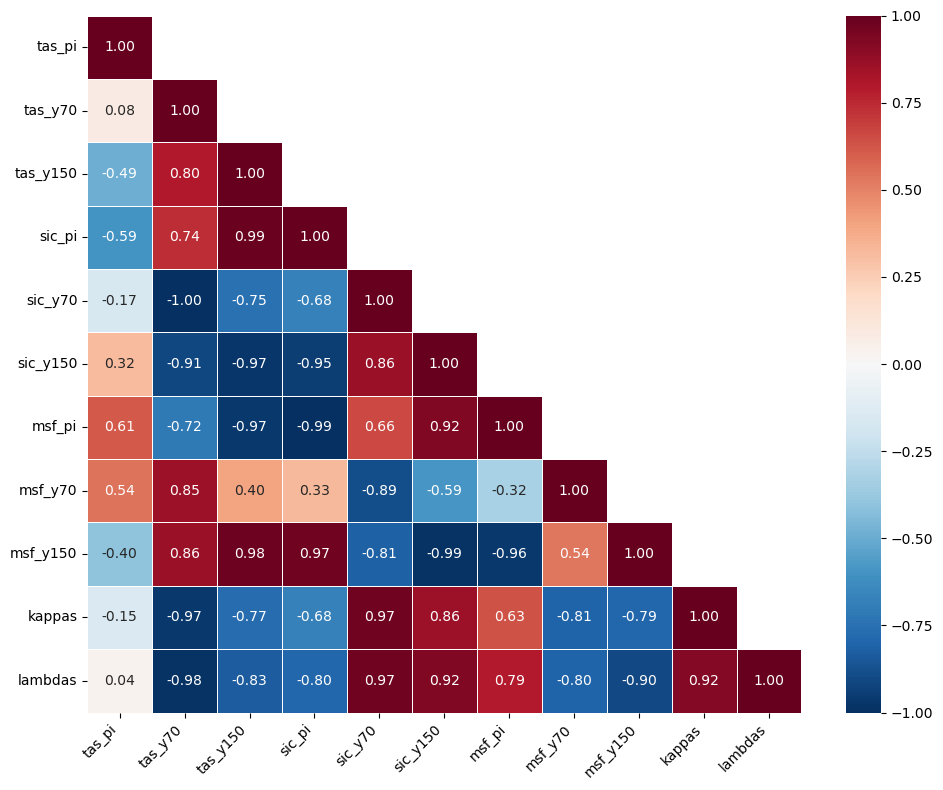

In [6]:
labels = ['tas_pi', 'tas_y70', 'tas_y150', 'sic_pi', 'sic_y70', 'sic_y150', 'msf_pi', 'msf_y70', 'msf_y150', 'kappas', 'lambdas']
arrays = [tas_pi, tas_year70, tas_year150, siconc_N_pi, siconc_N_year70, siconc_N_year150, msftyz_pi, msftyz_year70, msftyz_year150, kappas, lambdas]
import seaborn as sns
df = np.array(arrays)
corr = np.corrcoef(df)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # mask upper triangle

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# OHUE

Compute K from atmospheric and ocean variables

pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct4
coupled
Already computed, reading clim..
pic4
coupled
Already computed, reading clim..
1pc0
coupled
Already computed, reading clim..
ctl0
coupled
Already computed, reading clim..


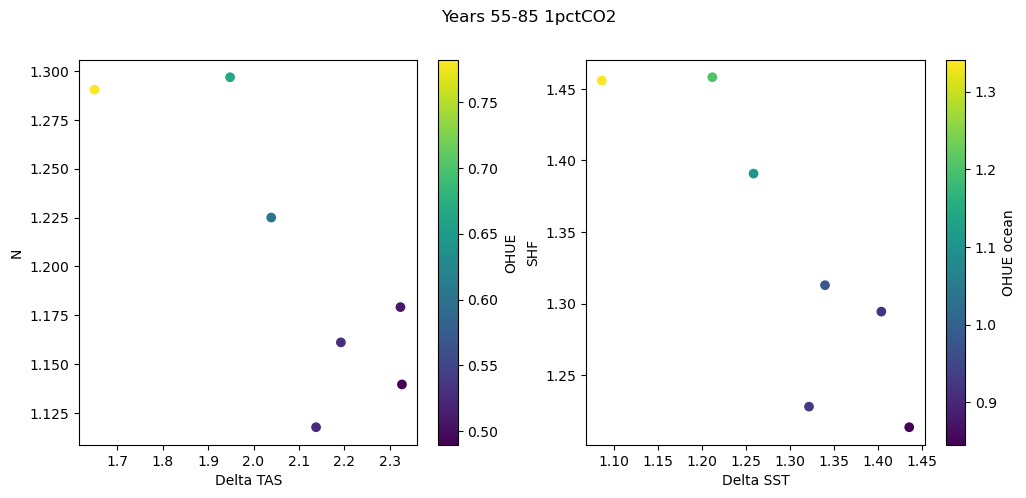

In [14]:
imp.reload(cr)
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].set_xlabel('Delta TAS')
ax[0].set_ylabel('N')

ax[1].set_xlabel('Delta SST')
ax[1].set_ylabel('SHF')

x = []
y = []
z = []

x1 = []
y1 =[]
z1 =[]

plt.suptitle('Years 55-85 1pctCO2')
for i, exp in enumerate(exps):
    _, ohue, tas, N, ohue_oce, tos, shf = cr.compute_ohue(exp, 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out)
    x.append(tas)
    y.append(N)
    z.append(ohue)

    x1.append(tos)
    y1.append(shf)
    z1.append(ohue_oce)

scatter = ax[0].scatter(x,y, c=z, cmap='viridis')
plt.colorbar(scatter, label='OHUE')

scatter1 = ax[1].scatter(x1,y1, c=z1, cmap='viridis')
plt.colorbar(scatter1, label='OHUE ocean')

plt.show()

pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct4
coupled
Already computed, reading clim..
pic4
coupled
Already computed, reading clim..
1pc0
coupled
Already computed, reading clim..
ctl0
coupled
Already computed, reading clim..


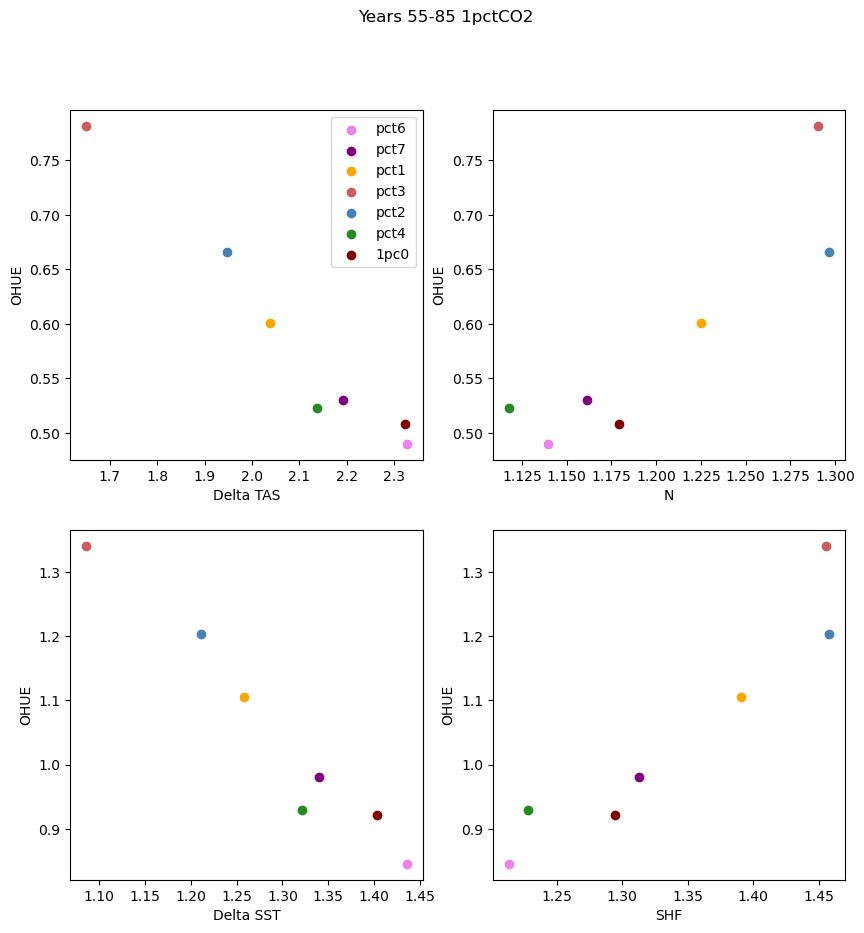

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
ax[0,0].set_xlabel('Delta TAS')
ax[0,0].set_ylabel('OHUE')

ax[0,1].set_xlabel('N')
ax[0,1].set_ylabel('OHUE')

ax[1,0].set_xlabel('Delta SST')
ax[1,0].set_ylabel('OHUE')

ax[1,1].set_xlabel('SHF')
ax[1,1].set_ylabel('OHUE')

plt.suptitle('Years 55-85 1pctCO2')
for i, exp in enumerate(exps):
    _, ohue, tas, N, ohue_oce, tos, shf = cr.compute_ohue(exp, 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out)
    ax[0,0].scatter(tas, ohue, color=colors[i], label=exp[0])
    ax[1,0].scatter(tos, ohue_oce, color=colors[i], label=exp[0])

    ax[0,1].scatter(N, ohue, color=colors[i], label=exp[0])
    ax[1,1].scatter(shf, ohue_oce, color=colors[i], label=exp[0])

ax[0,0].legend()
plt.show()

pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct4
coupled
Already computed, reading clim..
pic4
coupled
Already computed, rea

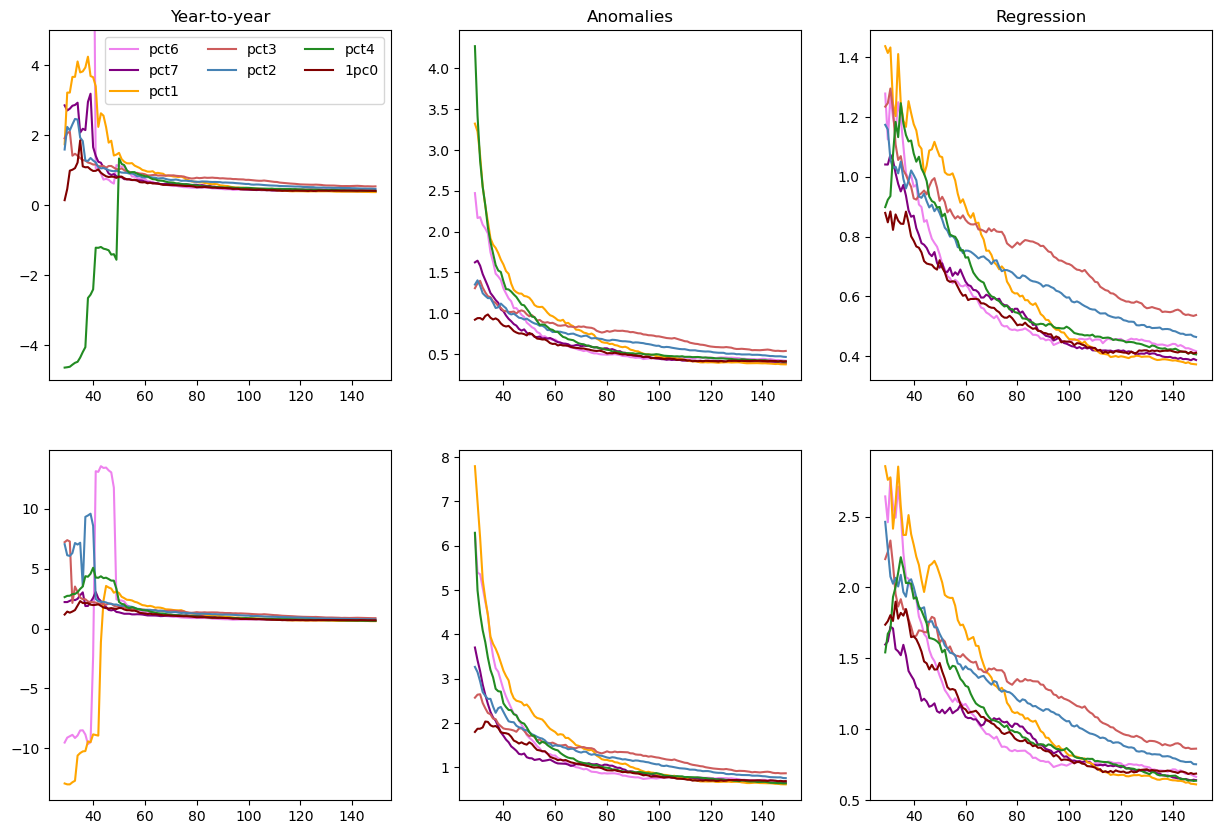

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(15,10))
imp.reload(cr)
for i, exp in enumerate(exps):

    cr.plot_ohue_ts(exps[i], 2*['itcv'], ax=ax, color=colors[i],cart_exp=cart_exp, cart_out=cart_out, rolling=30)

ax[0,0].set_ylim(-5,5)
ax[0,0].set_title('Year-to-year')
ax[0,1].set_title('Anomalies')
ax[0,2].set_title('Regression')
ax[0,0].legend(ncol=3)
plt.show()

# Checks with forcing and lambda

Need to adjust check_run to have proper output each time

pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct4
coupled
Already computed, reading clim..
pic4
coupled
Already computed, reading clim..
1pc0
coupled
Already computed, reading clim..
ctl0
coupled
Already computed, reading clim..


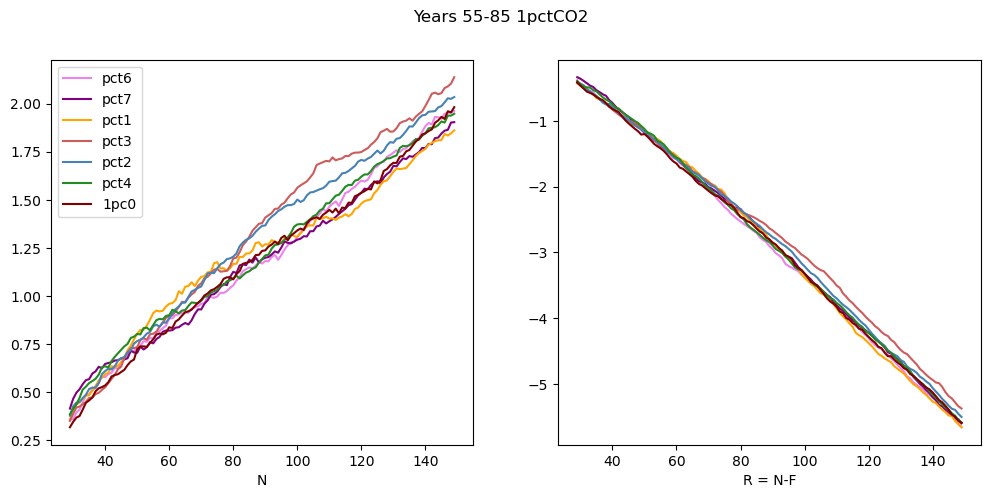

In [6]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
imp.reload(cr)

plt.suptitle('Years 55-85 1pctCO2')
for i, exp in enumerate(exps):
    N, T, F = cr.compute_lambda(exp, 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out)
    ax[0].plot(N.rolling(year=30).mean(), color=colors[i], label=exp[0])
    ax[1].plot((N-F).rolling(year=30).mean(), color=colors[i], label=exp[0])

ax[0].set_xlabel('N')
ax[1].set_xlabel('R = N-F')
ax[0].legend()
plt.show()

pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct4
coupled
Already computed, reading clim..
pic4
coupled
Already computed, reading clim..
1pc0
coupled
Already computed, reading clim..
ctl0
coupled
Already computed, reading clim..


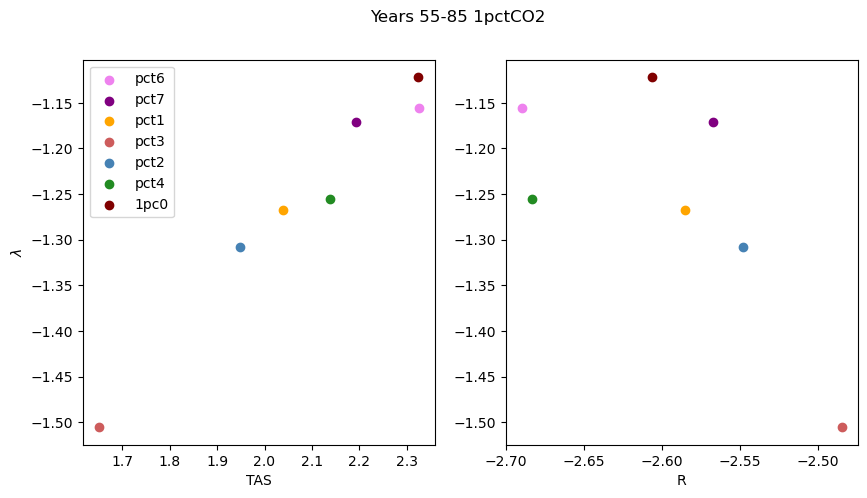

In [8]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
imp.reload(cr)
plt.suptitle('Years 55-85 1pctCO2')
for i, exp in enumerate(exps):
    feedback, R, T = cr.compute_lambda(exp, 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out)
    ax[0].scatter(T, feedback, color=colors[i], label=exp[0])
    ax[1].scatter(R, feedback, color=colors[i], label=exp[0])

ax[0].set_ylabel(r'$\lambda$')
ax[0].set_xlabel('TAS')
ax[1].set_xlabel('R')
ax[0].legend()
plt.show()

pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
abr6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
abr7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
abr1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
abr3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
abr2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct4
coupled
Already computed, reading clim..
pic4
coupled
Already computed, rea

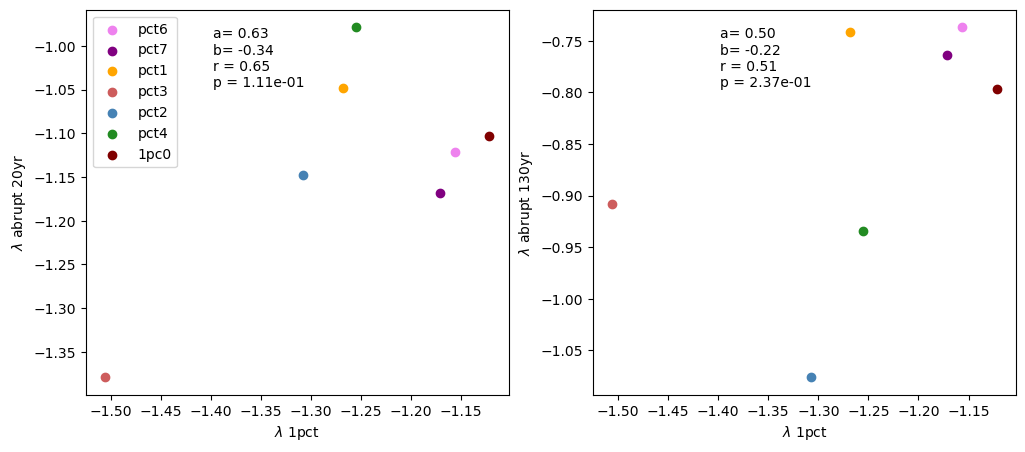

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

exps = [['pct6', 'pic6'],['pct7', 'pic7'],['pct1', 'pic1'], ['pct3', 'pic3'], ['pct2', 'pic2'], ['pct4', 'pic4'], ['1pc0', 'ctl0']]
exps_a = [ ['abr6', 'pic6'], ['abr7', 'pic7'],  ['abr1', 'pic1'],['abr3', 'pic3'], ['abr2', 'pic2'], ['abr4', 'pic4'], ['abr0', 'ctl0']]

colors = ['violet', 'purple', 'orange','indianred', 'steelblue','forestgreen','maroon']

lambdas_20 = []
lambdas_130 = []
lambdas_1pct = []

for i, exp in enumerate(exps):
    feedback, N, T = cr.compute_lambda(exp, 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out)
    feedback_A, N_a, T_a = cr.compute_alpha_abrupt(exps_a[i], 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out)
    
    L_20 = stats.linregress(T_a.sel(year =slice(1850,1869)), N_a.sel(year =slice(1850,1869)))[0]
    L_130 = stats.linregress(T_a.sel(year =slice(1870,2000)), N_a.sel(year =slice(1870,2000)))[0]
    
    ax[0].scatter(feedback, L_20, color=colors[i], label=exp[0])
    ax[1].scatter(feedback, L_130,color=colors[i], label=exp[0])

    lambdas_20.append(L_20)
    lambdas_130.append(L_130)      
    lambdas_1pct.append(feedback)

a, b, r_value, p_value, std_err =  stats.linregress(lambdas_1pct, lambdas_20)
ax[0].text(0.3,0.8, f'a= {a:.2f}\nb= {b:.2f}\nr = {r_value:.2f}\np = {p_value:.2e}', transform=ax[0].transAxes)

a, b, r_value, p_value, std_err =  stats.linregress(lambdas_1pct, lambdas_130)
ax[1].text(0.3,0.8,f'a= {a:.2f}\nb= {b:.2f}\nr = {r_value:.2f}\np = {p_value:.2e}', transform=ax[1].transAxes)

ax[0].set_ylabel(r'$\lambda$ abrupt 20yr')
ax[1].set_ylabel(r'$\lambda$ abrupt 130yr')
ax[0].set_xlabel(r'$\lambda$ 1pct')
ax[1].set_xlabel(r'$\lambda$ 1pct')
ax[0].legend()
plt.show()

These two function compute just a 30 year time window around year 70!

In [8]:
kappas = np.array([0.84123329, 0.99007471, 1.0855393 , 1.3471938 , 1.19594174,0.92113063, 0.90884158])
lambdas = np.array([1.15206076, 1.15950603, 1.26772497, 1.4947282 , 1.30711237,1.2470465 , 1.12615353])

In [ ]:
# imp.reload(cr)

# lambdas70 = []
# kappas70 = []

# for i, exp in enumerate(exps):
#     feedback, N, T = cr.compute_lambda(exp, 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out)
#     _,_,_,_,ohue_oce,_,_ = cr.compute_ohue(exp, 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out)

#     lambdas70.append(abs(feedback))
#     kappas70.append(ohue_oce)

From here I can test how correlation changes if I remove one point

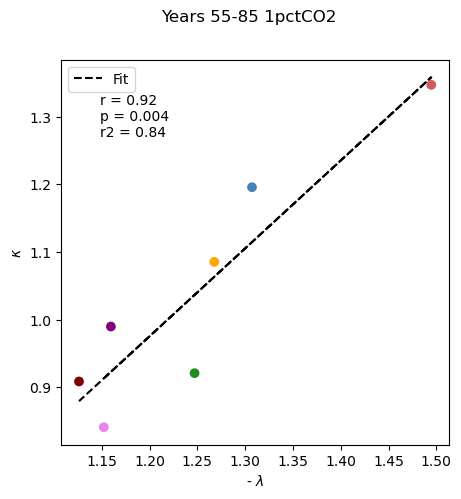

In [36]:
fig, ax = plt.subplots(1,1, figsize=(5,5))
imp.reload(cr)

plt.suptitle('Years 55-85 1pctCO2')
reg_indices = [0,1,2,3,4,5,6]

ax.scatter(lambdas[reg_indices], kappas[reg_indices], color=colors)
# y = ax+b
a, b, r_value, p_value, std_err =  stats.linregress(lambdas[reg_indices], kappas[reg_indices])
ax.plot(lambdas, [a*x + b for x in lambdas], color='black', linestyle='--', label='Fit')

ax.set_xlabel(r'- $\lambda$')
ax.set_ylabel(r'$\kappa$')
ax.legend()

ax.text(0.1, 0.8, f'r = {r_value:.2f}\np = {np.round(p_value,3)}\nr2 = {r_value**2:.2f}', transform=ax.transAxes)
plt.show()

pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct4
coupled
Already computed, reading clim..
pic4
coupled
Already computed, rea

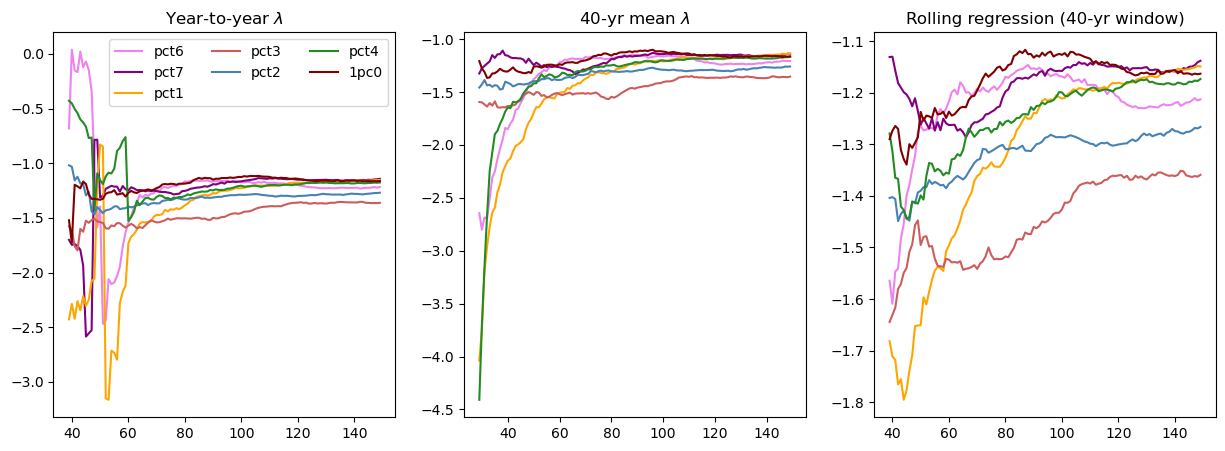

In [37]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
imp.reload(cr)
for i, exp in enumerate(exps):

    cr.plot_lambda_ts(exps[i], 2*['itcv'], ax=ax, color=colors[i],cart_exp=cart_exp, cart_out=cart_out, rolling=30)

ax[0].legend(ncol=3)
plt.show()

Compute timeseries of kappa and lambda. Each point is the mean of the previous N years

In [6]:
imp.reload(cr)
lambdas_ts = []
kappas_ts = []

window = 30
for i, exp in enumerate(exps):
    ohue = cr.compute_ohue(exp, 2*['itcv'],cart_exp=cart_exp, cart_out=cart_out, window=window)[0]
    feedback = cr.compute_lambda(exps[i], 2*['itcv'], cart_exp=cart_exp, cart_out=cart_out, window=window)
    
    lambdas_ts.append(abs(feedback))
    kappas_ts.append(ohue)


pct6
coupled
Already computed, reading clim..


pic6
coupled
Already computed, reading clim..
pct6
coupled
Already computed, reading clim..
pic6
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct7
coupled
Already computed, reading clim..
pic7
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct1
coupled
Already computed, reading clim..
pic1
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct3
coupled
Already computed, reading clim..
pic3
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct2
coupled
Already computed, reading clim..
pic2
coupled
Already computed, reading clim..
pct4
coupled
Already computed, reading clim..
pic4
coupled
Already computed, reading clim..
pct4
coupled
Already computed, rea

In [42]:
from statsmodels.regression.rolling import RollingOLS

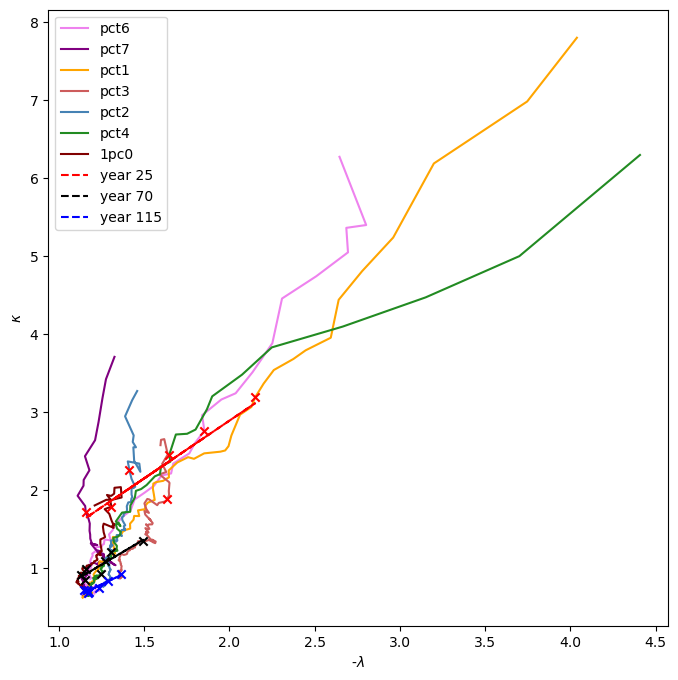

In [48]:
fig3, ax3 = plt.subplots(1,1, figsize=(8,8))

for i in range(len(exps)):
    
    ax3.plot(lambdas_ts[i], kappas_ts[i][:150], color=colors[i], label=exps[i][0] )
    
lambdas_ts = np.array(lambdas_ts)
kappas_ts = np.array(kappas_ts)

ax3.scatter(lambdas_ts[:,40], kappas_ts[:,40],color='r', marker='x', zorder=10)
a, b, r_value, p_value, std_err =  stats.linregress(lambdas_ts[:,40], kappas_ts[:,40])
ax3.plot(lambdas_ts[:,40], [a*x + b for x in lambdas_ts[:,40]], color='r', linestyle='--', label='year 25')

ax3.scatter(lambdas_ts[:,85], kappas_ts[:,85],color='k', marker='x', zorder=10)
a, b, r_value, p_value, std_err =  stats.linregress(lambdas_ts[:,85], kappas_ts[:,85])
ax3.plot(lambdas_ts[:,85], [a*x + b for x in lambdas_ts[:,85]], color='black', linestyle='--', label='year 70')

ax3.scatter(lambdas_ts[:,130], kappas_ts[:,130],color='b', marker='x', zorder=10)
a, b, r_value, p_value, std_err =  stats.linregress(lambdas_ts[:,130], kappas_ts[:,130])
ax3.plot(lambdas_ts[:,130], [a*x + b for x in lambdas_ts[:,130]], color='b', linestyle='--', label='year 115')

#ax3.text(0.1, 0.8, f'r = {r_value:.2f}\np = {np.round(p_value,2)}\nr2 = {r_value**2:.2f}', transform=ax3.transAxes)

ax3.legend()
ax3.set_xlabel(r'-$\lambda$')
ax3.set_ylabel(r'$\kappa$')
plt.show()

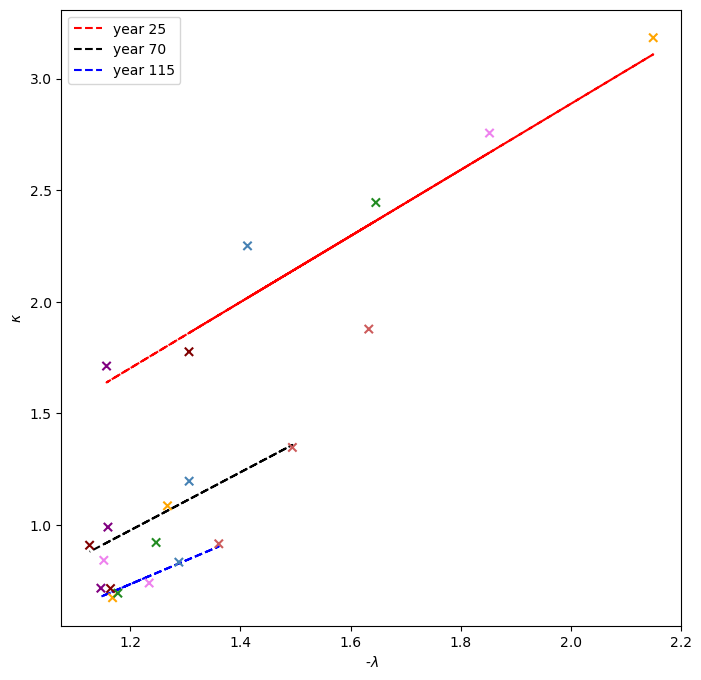

In [50]:
fig3, ax3 = plt.subplots(1,1, figsize=(8,8))

# for i in range(len(exps)):
    
#     ax3.plot(lambdas_ts[i], kappas_ts[i][:150], color=colors[i], label=exps[i][0] )
    
lambdas_ts = np.array(lambdas_ts)
kappas_ts = np.array(kappas_ts)

ax3.scatter(lambdas_ts[:,40], kappas_ts[:,40],color=colors, marker='x', zorder=10)
a, b, r_value, p_value, std_err =  stats.linregress(lambdas_ts[:,40], kappas_ts[:,40])
ax3.plot(lambdas_ts[:,40], [a*x + b for x in lambdas_ts[:,40]], color='r', linestyle='--', label='year 25')

ax3.scatter(lambdas_ts[:,85], kappas_ts[:,85],color=colors, marker='x', zorder=10)
a, b, r_value, p_value, std_err =  stats.linregress(lambdas_ts[:,85], kappas_ts[:,85])
ax3.plot(lambdas_ts[:,85], [a*x + b for x in lambdas_ts[:,85]], color='black', linestyle='--', label='year 70')

ax3.scatter(lambdas_ts[:,130], kappas_ts[:,130],color=colors, marker='x', zorder=10)
a, b, r_value, p_value, std_err =  stats.linregress(lambdas_ts[:,130], kappas_ts[:,130])
ax3.plot(lambdas_ts[:,130], [a*x + b for x in lambdas_ts[:,130]], color='b', linestyle='--', label='year 115')

#ax3.text(0.1, 0.8, f'r = {r_value:.2f}\np = {np.round(p_value,2)}\nr2 = {r_value**2:.2f}', transform=ax3.transAxes)

ax3.legend()
ax3.set_xlabel(r'-$\lambda$')
ax3.set_ylabel(r'$\kappa$')
plt.show()

0.9840025951748356 2.9495971570529127 -2.672781024342794
0.3147155525177327 3.03259838921206 -2.54550490164298
0.9927117293066161 2.4964283495732853 -2.1373602482555056
0.896588920225306 3.8229205647566302 -4.241593154577789
0.9130255735645618 8.373634676612877 -9.81605267718495
0.9369580282316534 2.21434722048912 -1.7304919723191445
0.9002240696039133 5.269911429614997 -5.234229742251738


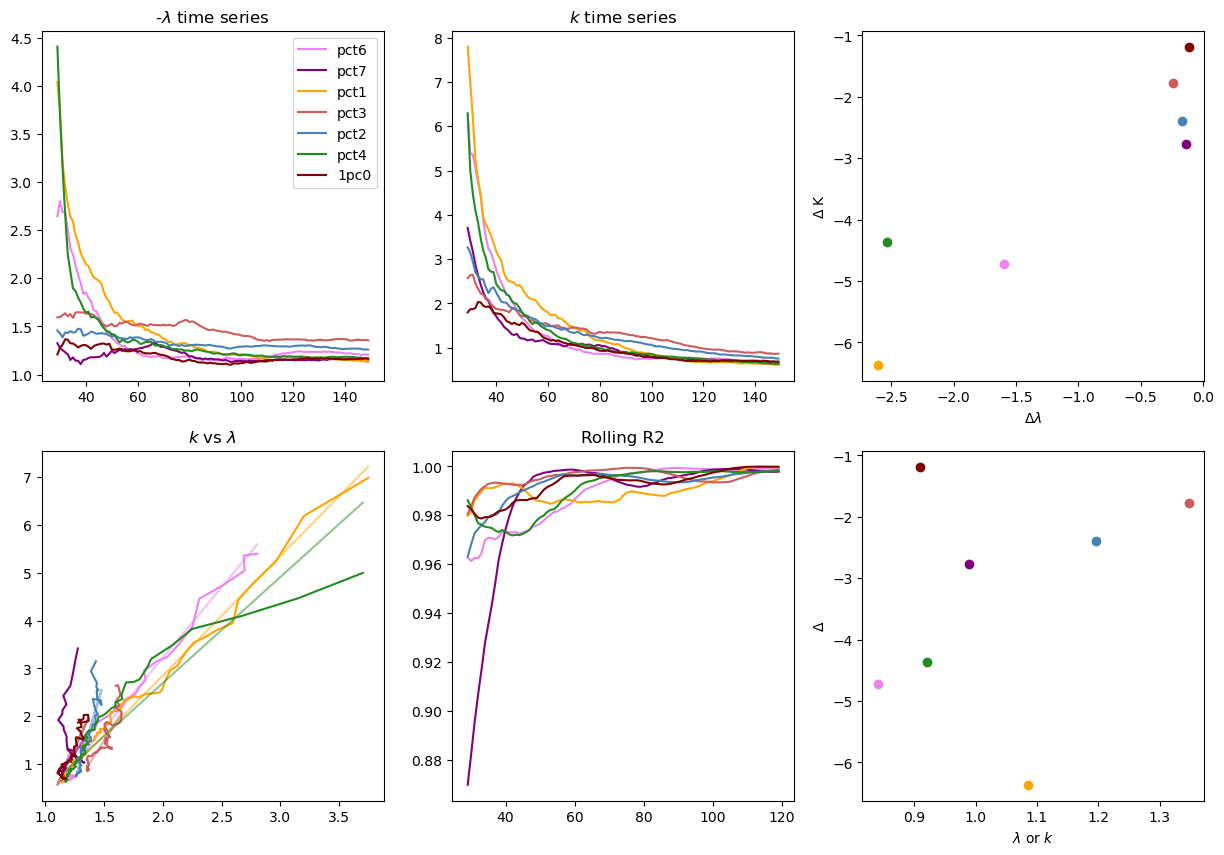

In [47]:
fig3, ax3 = plt.subplots(2,3, figsize=(15,10))

window = 30
for i in range(len(exps)):
    ax3[0,0].plot(lambdas_ts[i], color=colors[i], label=exps[i][0])
    ax3[0,1].plot(kappas_ts[i], color=colors[i], label=exps[i][0])
    
    #a, b, r_value, p_value, std_err =  stats.linregress(lambdas[i][window:].flatten(), kappas[i][window:150].flatten())
    a, b, r_value, p_value, std_err =  stats.linregress(lambdas_ts[i][window:], kappas_ts[i][window:150])

    print(r_value, a, b)
    #ax3[2].scatter(i, r_value, color=colors[i], label=exps[i][0])
    ax3[1,0].plot(lambdas_ts[i][window:], kappas_ts[i][window:150], color=colors[i], label=exps[i][0] )
    ax3[1,0].plot(lambdas_ts[i][window:], lambdas_ts[i][window:]*a+b, color=colors[i], label=exps[i][0],alpha=0.5 )

    y3 = RollingOLS(lambdas_ts[i][window:], kappas_ts[i][window:150], window=window)
    #y3 = RollingOLS(lambdas[i][window:].flatten(), kappas[i][window:150].flatten(), window=window)
    rres= y3.fit()
    ax3[1,1].plot(rres.rsquared,label = exps[i][0], color = colors[i])

    deltaL = lambdas_ts[i][-1] - lambdas_ts[i][window]
    deltaK = kappas_ts[i][149] - kappas_ts[i][window]
    ax3[0,2].scatter(deltaL, deltaK, color=colors[i])

    ax3[1,2].scatter(kappas_ts[i][85], deltaK,color=colors[i])
    #ax3[1,2].scatter(lambdas[i][85], deltaL, color=colors[i], marker='*')
    
ax3[0,0].legend()
ax3[0,0].set_title(r'-$\lambda$ time series')
ax3[0,1].set_title(r'$k$ time series')
ax3[1,0].set_title(r'$k$ vs $\lambda$')
ax3[1,1].set_title('Rolling R2')
ax3[0,2].set_xlabel(r'$\Delta \lambda$')
ax3[0,2].set_ylabel(r'$\Delta$ K')
ax3[1,2].set_xlabel(r'$\lambda$ or $k$')
ax3[1,2].set_ylabel(r'$\Delta$')
plt.show()

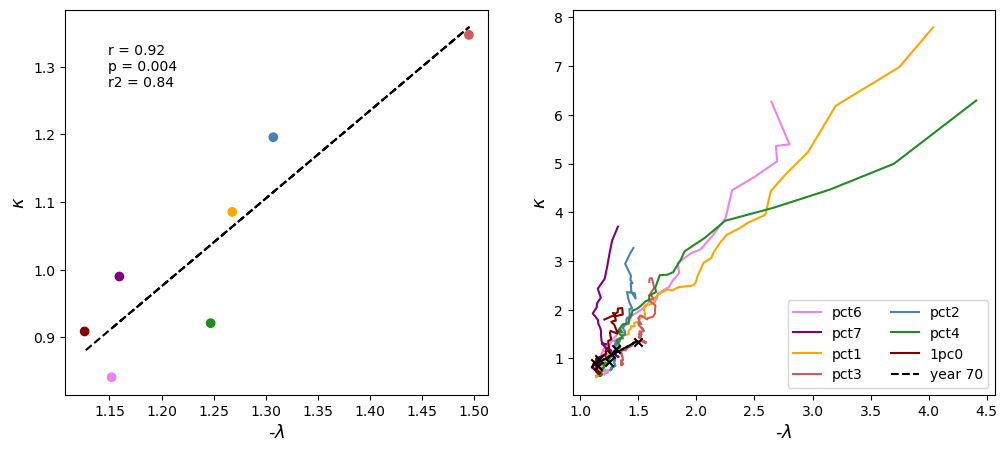

In [16]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
imp.reload(cr)

#plt.suptitle('Years 55-85 1pctCO2')
reg_indices = [0,1,2,3,4,5,6]

ax[0].scatter(lambdas[reg_indices], kappas[reg_indices], color=colors)
# y = ax+b
a, b, r_value, p_value, std_err =  stats.linregress(lambdas[reg_indices], kappas[reg_indices])
ax[0].plot(lambdas, [a*x + b for x in lambdas], color='black', linestyle='--', label='Fit')

ax[0].set_xlabel(r'-$\lambda$', fontsize=13)
ax[0].set_ylabel(r'$\kappa$', fontsize=13)
ax[0].text(0.1, 0.8, f'r = {r_value:.2f}\np = {np.round(p_value,3)}\nr2 = {r_value**2:.2f}', transform=ax[0].transAxes)

for i in range(len(exps)):
    
    ax[1].plot(lambdas_ts[i], kappas_ts[i][:150], color=colors[i], label=exps[i][0] )
    
lambdas_ts = np.array(lambdas_ts)
kappas_ts = np.array(kappas_ts)

ax[1].scatter(lambdas_ts[:,85], kappas_ts[:,85],color='k', marker='x', zorder=10)
a, b, r_value, p_value, std_err =  stats.linregress(lambdas_ts[:,85], kappas_ts[:,85])
ax[1].plot(lambdas_ts[:,85], [a*x + b for x in lambdas_ts[:,85]], color='black', linestyle='--', label='year 70')

#ax3.text(0.1, 0.8, f'r = {r_value:.2f}\np = {np.round(p_value,2)}\nr2 = {r_value**2:.2f}', transform=ax3.transAxes)

ax[1].legend(ncol=2)
ax[1].set_xlabel(r'-$\lambda$', fontsize=13)
ax[1].set_ylabel(r'$\kappa$', fontsize=13)
plt.show()